In [3]:
import numpy as np
import cv2 
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import scipy


plt.rcParams['image.origin'] = 'lower'
plt.rcParams['image.cmap'] = 'inferno'
np.set_printoptions(suppress=True)


In [4]:
dir = '/Users/mleclair/phd/code/dunex/data/argus'
file = 'ArgusFF_20211013T170100Z_RectifiedVideo.avi'
os.path.join(dir, file) 

'/Users/mleclair/phd/code/dunex/data/argus/ArgusFF_20211013T170100Z_RectifiedVideo.avi'

In [5]:
cap = cv2.VideoCapture(os.path.join(dir, file))
N = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f'{np.zeros((N, W), dtype=np.uint8).nbytes/1000/1000}mb per timestack')

# NOTE: We're downsampling in along-shore to 10m
skip = 1
timestack = np.zeros((N, H//skip, W))


for i in tqdm(range(N)):
    _, frame = cap.read()
    timestack[i] = frame[::skip, :, 0]

cap.release()
cv2.destroyAllWindows()

1.92mb per timestack


  0%|          | 0/3840 [00:00<?, ?it/s]

100%|██████████| 3840/3840 [00:09<00:00, 403.55it/s]


In [85]:
fk_stack = timestack[:, 700:900, 300:500]
# fk_stack = timestack[:, 850:900, 450:500]
# fk_stack = timestack[:, 880:900, 480:500]
# fk_stack = timestack[:, 870:900, 470:500]
# del timestack
# fk_stack = timestack[:, 890:900, 390:400]
# fk_stack = fk_stack - fk_stack.mean()


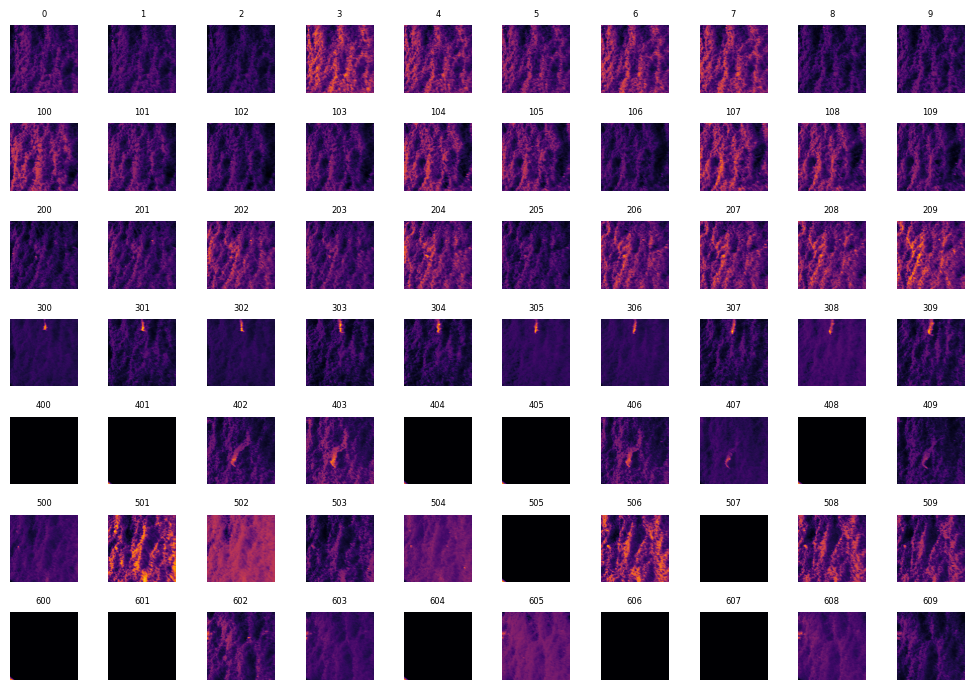

In [86]:
fig, axs = plt.subplots(7, 10, figsize=(10, 7))
for i, row in enumerate(axs):
    for j, col in enumerate(row):
        col.imshow(fk_stack[i*100 + j, ...])
        col.axis('off')
        col.set_title(i*100 + j, fontsize=6)
plt.tight_layout()
# plt.imshow(off_shore[0, ...])

In [87]:
fk_stack = fk_stack[:300, ...]
fk_stack.shape

(300, 200, 200)

w shape: (150,)
kx shape: (200,)
Fwkk shape: (150, 200, 200)


/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_70912/2659863423.py:53: RuntimeWarning: divide by zero encountered in log10
  plt.pcolormesh(*np.meshgrid(ky, kx), np.log10(Fwkk.mean(0)), shading='nearest')


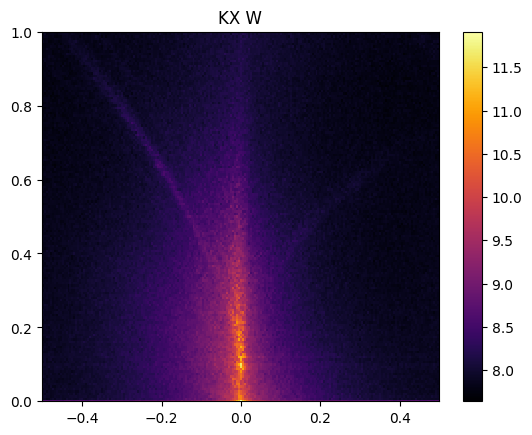

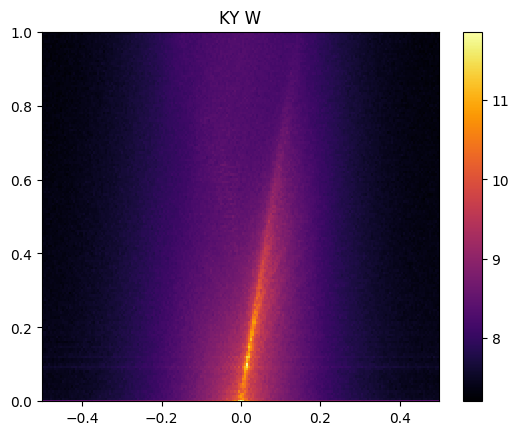

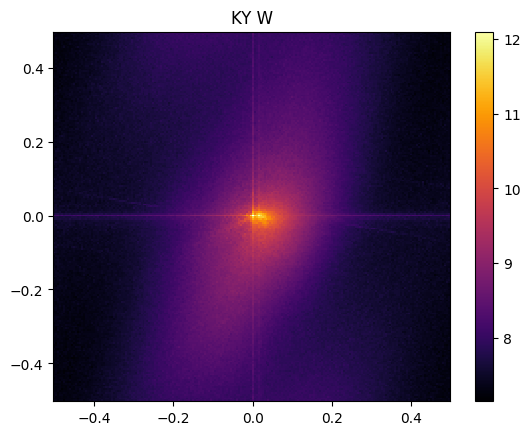

In [88]:
from scipy.fft import fftn
import numpy as np
import matplotlib.pyplot as plt

fs = 2
w = np.fft.fftshift(np.fft.fftfreq(fk_stack.shape[0], d=1/fs))[len(fk_stack)//2:] # Just positive frequencies
kx =  np.fft.fftshift(np.fft.fftfreq(fk_stack.shape[1], d=1))
ky = kx.copy()
dw = w[1]-w[0]
dkx = kx[1]-kx[0]
dky = ky[1]-ky[0]

Fwkk = scipy.fft.fftn(fk_stack - fk_stack.mean())
Fwkk = scipy.fft.fftshift(Fwkk)[len(Fwkk)//2:] # Just positive frequencies
Fwkk = Fwkk/np.size(fk_stack)
Fwkk = np.abs(Fwkk/(dkx * dky * dw))**2 # Power Spectrum





# Fwkk = Fwkk/np.nansum(Fwkk) # Normalize
Fwkk[:, len(kx)//2, len(ky)//2] = 0
print(f"w shape: {w.shape}")
print(f"kx shape: {kx.shape}")
print(f"Fwkk shape: {Fwkk.shape}")


d = 7.5

plt.figure()
plt.title('KX W')
plt.pcolormesh(*np.meshgrid(kx, w), np.log10(Fwkk.mean(2)), shading='nearest')
U = (-1, -7)
w_ = np.sqrt(9.8*kx*np.tanh(kx*d)) 
# plt.plot(kx, w_, alpha=0.5)
# plt.plot(kx, w_ + kx * U[1], alpha=0.5)
plt.ylim((0, 1))
plt.colorbar()

plt.figure()
plt.title('KY W')
plt.pcolormesh(*np.meshgrid(ky, w), np.log10(Fwkk.mean(1)), shading='nearest')
w_ = np.sqrt(9.8*ky*np.tanh(kx*d))
# plt.plot(ky, w_, alpha=0.5)
# plt.plot(ky, w_ + ky * U[0], alpha=0.5)
plt.ylim((0, 1))
plt.colorbar()


plt.figure()
plt.title('KY W')
plt.pcolormesh(*np.meshgrid(ky, kx), np.log10(Fwkk.mean(0)), shading='nearest')
plt.colorbar()
# U = (1, 0)
# w_ = np.sqrt(9.8*ky*np.tanh(kx*8)) #+ np.dot(kx, U)
# plt.plot(kx, w_)
# plt.ylim((0, 1))



/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_70912/1318399314.py:5: RuntimeWarning: divide by zero encountered in log10
  col.imshow(np.log10(Fwkk[ij, ...]), vmin=7, vmax=12)


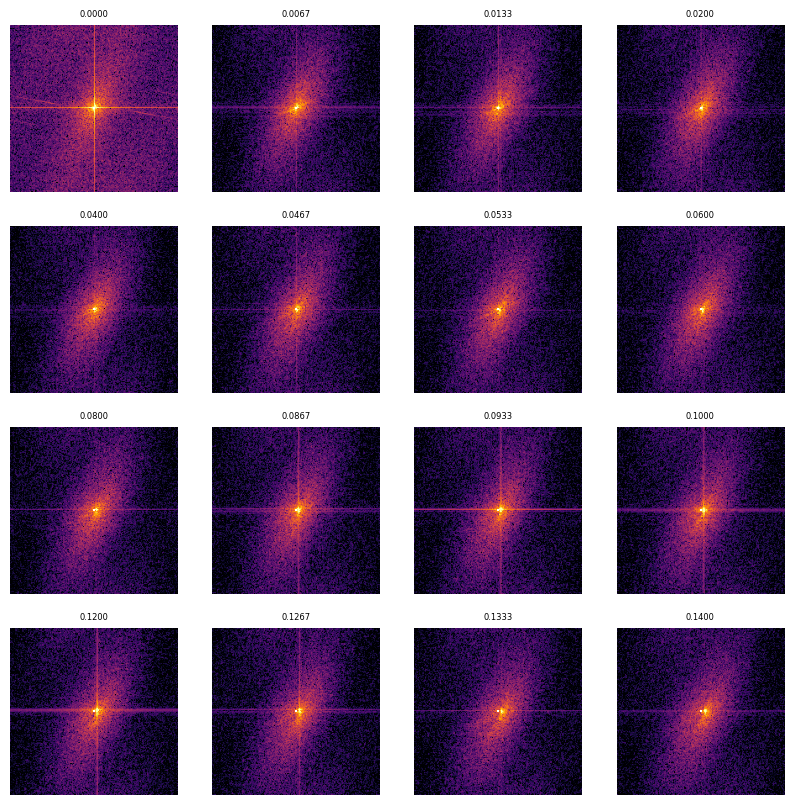

In [89]:
fig, axs = plt.subplots(4, 4, figsize=(10, 10))
for i, row in enumerate(axs):
    for j, col in enumerate(row):
        ij = i*6 + j
        col.imshow(np.log10(Fwkk[ij, ...]), vmin=7, vmax=12)
        col.axis('off')
        col.set_title(f'{w[ij]:.4f}', fontsize=6)
        # col.set_title(i*6 + j, fontsize=6)

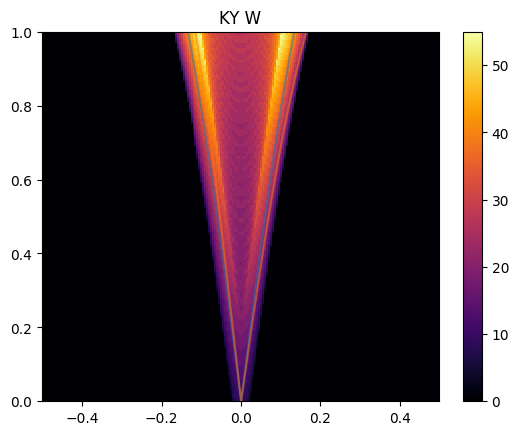

In [90]:
Fwkk_filt = np.zeros_like(Fwkk)

for i, w_ in enumerate(w):
    for j, ky_ in enumerate(ky):
        # for k, kx_ in enumerate(kx):
        mk = np.sqrt(kx**2 + ky_**2)
        dist = (w_-np.sqrt(9.81*mk*np.tanh(mk*d)))
        thickness = 0.2
        Fwkk_filt[i,j,:] = (dist <= thickness) & (dist >= -thickness)


plt.figure()
plt.title('KY W')
plt.pcolormesh(*np.meshgrid(ky, w), (np.abs(Fwkk_filt.sum(1))**1), shading='nearest')
w_ = np.sqrt(9.8*ky*np.tanh(kx*d))
plt.plot(ky, w_, alpha=0.5)
plt.plot(ky, w_ + ky * U[0], alpha=0.5)
plt.ylim((0, 1))
plt.colorbar()

/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_70912/2208849579.py:15: RuntimeWarning: divide by zero encountered in log10
  plt.pcolormesh(*np.meshgrid(kx, w), np.log10(Fwkk_filt.mean(2)), shading='nearest')
/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_70912/2208849579.py:25: RuntimeWarning: divide by zero encountered in log10
  plt.pcolormesh(*np.meshgrid(ky, w), np.log10(Fwkk_filt.mean(1)), shading='nearest')
/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_70912/2208849579.py:35: RuntimeWarning: divide by zero encountered in log10
  plt.pcolormesh(*np.meshgrid(ky, kx), np.log10(Fwkk_filt.mean(0)), shading='nearest')


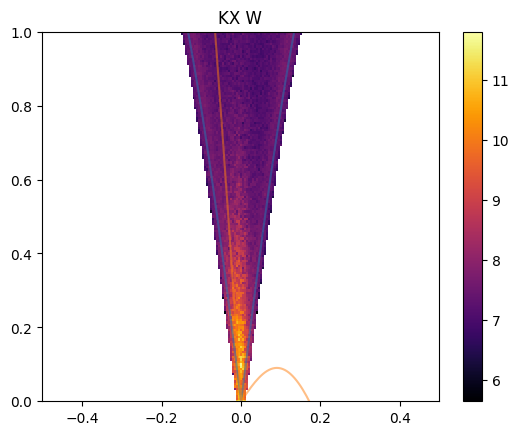

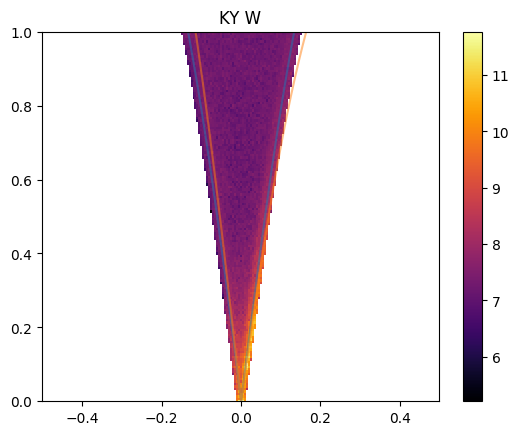

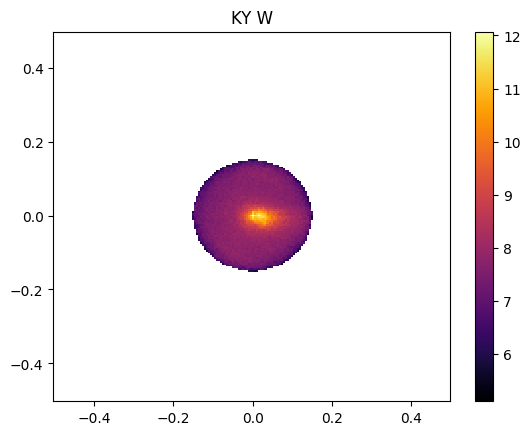

In [91]:
Fwkk_filt = np.zeros_like(Fwkk)
w_ = np.sqrt(9.8*ky*np.tanh(ky*d))
for i, w_ in enumerate(w):
    for j, ky_ in enumerate(ky):
        # for k, kx_ in enumerate(kx):
        mk = np.sqrt(kx**2 + ky_**2)
        dist = (w_-np.sqrt(9.81*mk*np.tanh(mk*d)))
        # if (dist <= 0.1) & (dist >= 0):
        thickness = 0.1
        shell = (dist <= thickness) & (dist >= -thickness)
        Fwkk_filt[i,j,shell] = Fwkk[i,j,shell] 
            
plt.figure()
plt.title('KX W')
plt.pcolormesh(*np.meshgrid(kx, w), np.log10(Fwkk_filt.mean(2)), shading='nearest')
U = (-1, -7)
w_ = np.sqrt(9.8*kx*np.tanh(kx*d)) 
plt.plot(kx, w_, alpha=0.5)
plt.plot(kx, w_ + kx * U[1], alpha=0.5)
plt.ylim((0, 1))
plt.colorbar()

plt.figure()
plt.title('KY W')
plt.pcolormesh(*np.meshgrid(ky, w), np.log10(Fwkk_filt.mean(1)), shading='nearest')
w_ = np.sqrt(9.8*ky*np.tanh(kx*d))
plt.plot(ky, w_, alpha=0.5)
plt.plot(ky, w_ + ky * U[0], alpha=0.5)
plt.ylim((0, 1))
plt.colorbar()


plt.figure()
plt.title('KY W')
plt.pcolormesh(*np.meshgrid(ky, kx), np.log10(Fwkk_filt.mean(0)), shading='nearest')
plt.colorbar()

/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_70912/2621880109.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  my_cmap = plt.cm.get_cmap('inferno')
/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_70912/2621880109.py:16: RuntimeWarning: divide by zero encountered in divide
  im = ax.scatter(theta.flatten(), f.flatten(), c=np.log10(np.abs(Fft).T.flatten() + 1e-11), s=1/k, vmin=8, vmax=13)


Text(0.5, 1.0, 'F, $\\theta$')

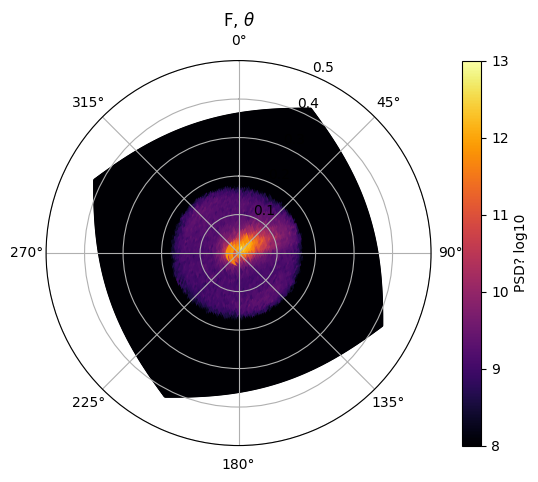

In [105]:
Fkk_filt = Fwkk_filt.sum(0)

X, Y = np.meshgrid(kx, ky)
k = np.sqrt(X**2 + Y**2)
f = np.sqrt(9.8*k*np.tanh(k*d)+1e-10)/2/np.pi # omega / 2 pi = np.sqrt(gk tanh(kd))
theta = np.arctan2(X, Y) + np.deg2rad(90 - 18.15)
dkdf=2
Fft = k * dkdf * Fkk_filt

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8,5))
my_cmap = plt.cm.get_cmap('inferno')
my_cmap.set_under('lightgrey')

ax.set_theta_direction(-1)
ax.set_theta_zero_location("N")
im = ax.scatter(theta.flatten(), f.flatten(), c=np.log10(np.abs(Fft).T.flatten() + 1e-11), s=1/k, vmin=8, vmax=13)
plt.ylim((0, 0.5))
# im = ax.contourf(theta, f, np.log10(Fft.T+1e-11), cmap=my_cmap, levels=np.linspace(8, 13, 10))
# im = ax.pcolormesh(theta, k, np.log10(Fft.T+1e-11), cmap=my_cmap, vmin=8, vmax=13)
plt.colorbar(im, label='PSD? log10')
plt.title('F, $\\theta$')

In [106]:
Fkk = Fwkk_filt.sum(0)
r = np.linspace(0, 0.707, 1000)
r = np.sqrt(9.8 * r * np.tanh(r * d))
X, Y = np.meshgrid(kx, ky)
X, Y = np.meshgrid(kx, ky)
k = np.sqrt(X**2 + Y**2)
F = []#np.sqrt(9.8*k*np.tanh(k*d)+1e-10)/2/np.pi # omega / 2 pi = np.sqrt(gk tanh(kd))
Fwt = []
thetas = []
for i in range(len(r)-1):
    mask = (k > r[i]) & (k < r[i+1])
    Fwt.append(r[i]*2*(Fkk[mask]))
    thetas.append(np.arctan2(X[mask], Y[mask]))
    X, Y = np.meshgrid(kx, ky)
    k_ = np.sqrt(X[mask]**2 + Y[mask]**2)
    f = np.sqrt(9.8*k_*np.tanh(k_*d)+1e-10)/np.pi # omega / 2 pi = np.sqrt(gk tanh(kd))
    F.append(f)

/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_70912/1439984565.py:5: RuntimeWarning: divide by zero encountered in log10
  ax.scatter(thetas[i]-np.deg2rad(90-18.15), F[i], c=np.log10(Fwt[i]), s=50)


(0.0, 0.5)

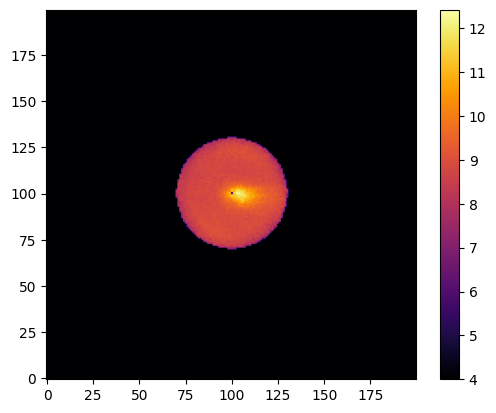

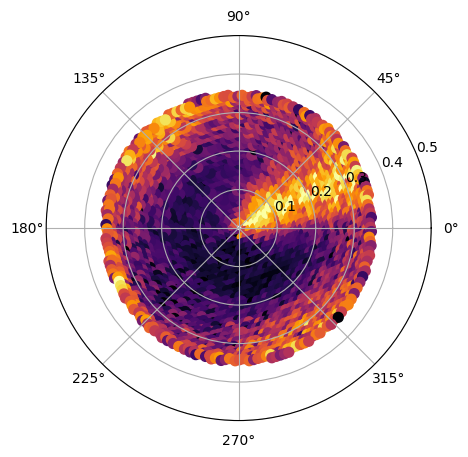

In [107]:
plt.imshow(np.log10(np.sqrt(X**2+Y**2) * Fkk + 1e4))
plt.colorbar()
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8,5))
for i in range(len(r)-1):
    ax.scatter(thetas[i]-np.deg2rad(90-18.15), F[i], c=np.log10(Fwt[i]), s=50)
plt.ylim((0, 0.5))

/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_70912/1212702143.py:3: RuntimeWarning: Mean of empty slice.
  ff.append(P.mean() / f.mean())


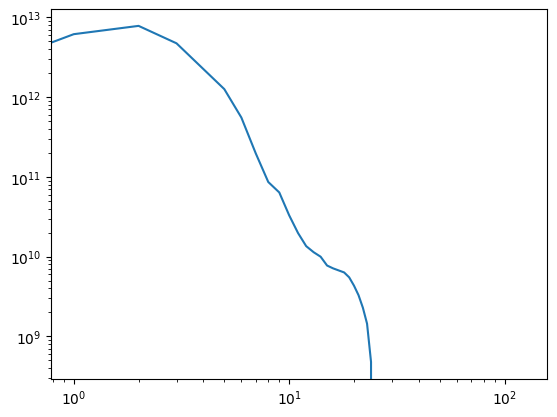

In [108]:
ff=[]
for f, P in zip(F, Fwt):
    ff.append(P.mean() / f.mean())
plt.loglog(ff)

/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_70912/2079321750.py:2: RuntimeWarning: divide by zero encountered in log10
  img = np.log10(Fwkk_filt.sum(0))


(1.719658863969133, 47.68387598150504, 8.758603978533325, 13.475758960413605)

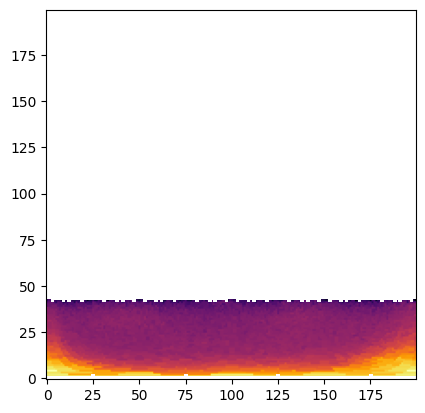

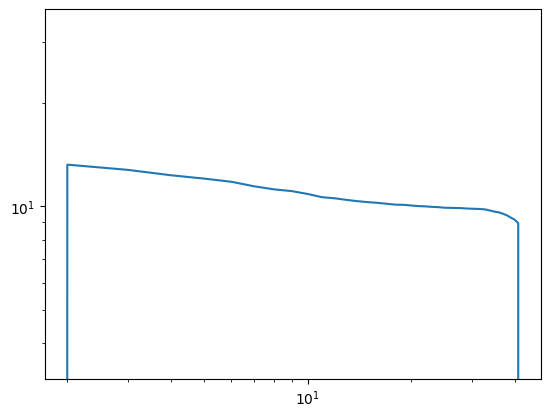

In [109]:
import cv2
img = np.log10(Fwkk_filt.sum(0))
value = np.sqrt(((img.shape[0]/2.0)**2.0)+((img.shape[1]/2.0)**2.0))
polar_image = cv2.linearPolar(img,(img.shape[0]/2, img.shape[1]/2), value, cv2.WARP_FILL_OUTLIERS)
polar_image[polar_image==0] = np.nan
plt.imshow(polar_image.T)
plt.figure()
plt.loglog(np.mean(polar_image[:125, :], axis=0))
plt.axis('equal')

In [110]:
import xarray as xr
import pandas as pd
mission_id = 32
ds = xr.load_dataset('../../model/data/FRF-ocean_waves_8m-array_202110.nc')
mission = xr.load_dataset(f'../../data/swift/doi_10_5061_dryad_hx3ffbgk0__v20230321/mission_{mission_id}.nc')
waves = ds.sel(time=mission.time.mean(), method='nearest')

mission_df_8m = pd.read_csv('../../data/mission_df.csv')
mission_df_8m[(mission_df_8m['mission number'] == 19) | 
              (mission_df_8m['mission number'] == 32) | 
              (mission_df_8m['mission number'] == 56)]

,Unnamed: 0,time,mission number,Hs [m],Tm [s],Mean Dir [deg],cross shore gamma location [m],break depth,freq [hz],energy density [m^2\hz],direction bins [deg],directional energy density [m^2/hz/deg],wind speed [m/s],wind direction [deg],water level [m]
6,6,2021-10-08 18:31:59.996640,19,1.153885,5.855787,67.689864,273.300564,3.296814,"[0.03999999910593033, 0.04749999940395355, 0.0...","[0.01377242289597856, 0.05397805134639883, 0.2...","[0.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 35.0,...","[[2.326480534975417e-05, 2.5262941562687047e-0...",8.237333,33.152010,-0.399
21,21,2021-10-25 17:33:29.996040,56,0.611392,5.873361,100.408665,204.804833,1.746834,"[0.03999999910593033, 0.04749999940395355, 0.0...","[0.005536946919848998, 0.010698302698486664, 0...","[0.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 35.0,...","[[6.697134267596994e-06, 7.14673251422937e-06,...",3.360000,188.820720,0.123
39,39,2021-10-13 17:25:29.998680,32,1.091753,6.456496,59.175695,263.470935,3.119293,"[0.03999999910593033, 0.04749999940395355, 0.0...","[0.01459356204863603, 0.013802312733134417, 0....","[0.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 35.0,...","[[4.0894119592849165e-05, 4.2284758819732815e-...",6.483833,4.238652,0.781


In [125]:
waves.cross_shore_angle

71.8

/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_70912/2575379128.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  my_cmap = (plt.cm.get_cmap('inferno'))
/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_70912/2575379128.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  my_cmap = plt.cm.get_cmap('inferno')


Text(0.5, 1.0, 'Mission 32 Image Wave Spectra [150s]\nImage Coordinates [700:900, 300:500]')

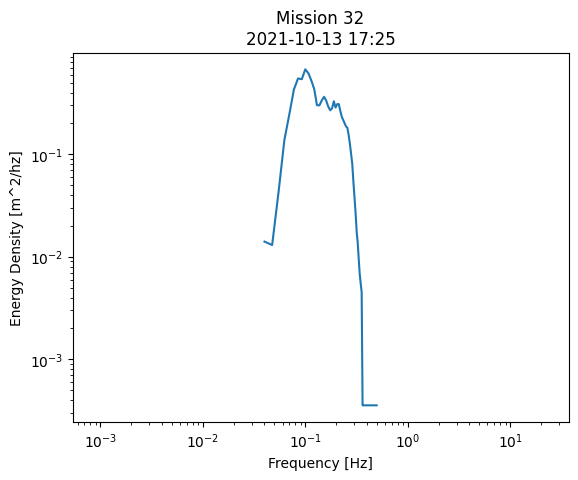

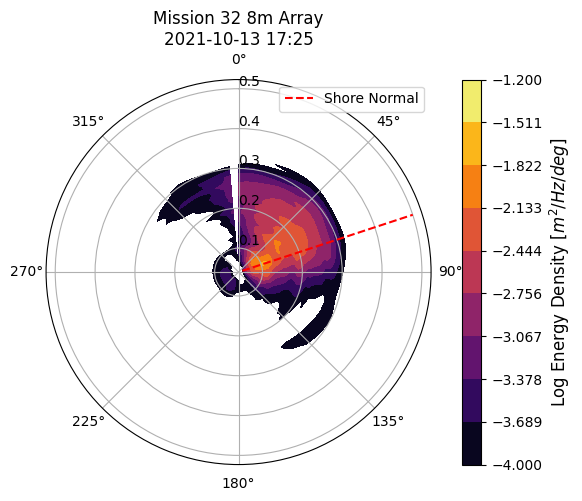

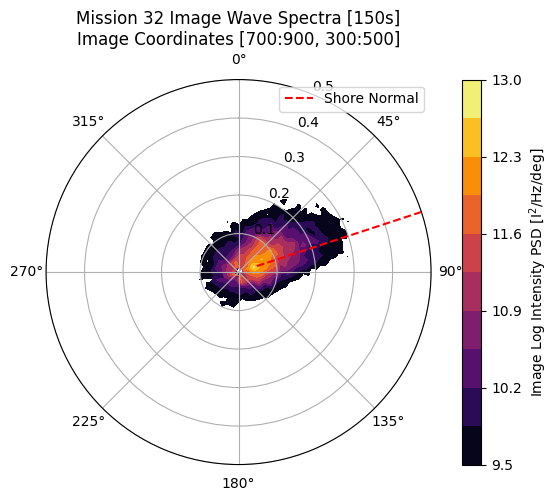

: 

In [148]:
# Plot a single directional spectra
dirs = waves['waveDirectionBins'].values
freqs = waves.waveFrequency
spectra = waves.waveEnergyDensity
dir_spectra = waves.directionalWaveEnergyDensity

theta, r = np.meshgrid(np.radians(dirs), freqs)

my_cmap = (plt.cm.get_cmap('inferno'))
my_cmap.set_under('lightgrey')

# Plot the 1d spectra
fig, ax = plt.subplots()
ax.loglog(freqs, spectra)
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Energy Density [m^2/hz]')
ax.set_title(
    f'Mission {mission_id}\n{mission_df_8m[(mission_df_8m['mission number'] == mission_id)]['time'].item()[:16]}')
plt.axis('equal')
# plot directional spectra
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8,5))
ax.set_theta_direction(-1)
ax.set_theta_zero_location("N")
ax.vlines(waves.cross_shore_angle * (np.pi/180), 0.05, 0.5, zorder=3, color='r', linestyle='dashed', label='Shore Normal')
# im = ax.pcolormesh(theta, r, dir_spectra, cmap=my_cmap, vmin=5e-04)
im = ax.contourf(theta, r, np.log10(dir_spectra), cmap=my_cmap, levels=np.linspace(-4, -1.2, 10))
cbar = fig.colorbar(im, extend='min', extendrect=True)

cbar.set_label('Log Energy Density [$m^2/Hz/deg$]', rotation=90, fontsize=12)
ax.legend()

# ax.set_rscale('log')
ax.set_rlabel_position(0)
ax.set_title(
    f'Mission {mission_id} 8m Array\n{mission_df_8m[(mission_df_8m['mission number'] == mission_id)]['time'].item()[:16]}')

Fkk_filt = Fwkk_filt.sum(0)

X, Y = np.meshgrid(kx, ky)
k = np.sqrt(X**2 + Y**2)
f = np.sqrt(9.8*k*np.tanh(k*d)+1e-10)/np.pi # omega / 2 pi = np.sqrt(gk tanh(kd))
theta = np.arctan2(X, Y) + np.deg2rad(90 - 18.15)
dkdf=2
Fft = k * dkdf * Fkk_filt

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8,5))
my_cmap = plt.cm.get_cmap('inferno')
my_cmap.set_under('lightgrey')

ax.set_theta_direction(-1)
ax.set_theta_zero_location("N")
ax.vlines(waves.cross_shore_angle * (np.pi/180), 0.05, 0.5, zorder=3, color='r', linestyle='dashed', label='Shore Normal')
# im = ax.scatter(theta.flatten(), f.flatten(), c=np.log10(np.abs(Fft).T.flatten() + 1e-11), s=4, vmin=9, vmax=13)
plt.ylim((0, 0.5))
im = ax.contourf(theta, f, np.log10(Fft.T+1e-11), cmap=my_cmap, levels=np.linspace(9.5, 13, 11))
plt.legend()
# im = ax.pcolormesh(theta, k, np.log10(Fft.T+1e-11), cmap=my_cmap, vmin=8, vmax=13)
plt.colorbar(im, label='Image Log Intensity PSD [I$^2$/Hz/deg]')
plt.title(f'Mission 32 Image Wave Spectra [{fk_stack.shape[0]/2:.0f}s]\nImage Coordinates [700:900, 300:500]')

In [135]:
timestack

71.8

/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_70912/4211526288.py:3: RuntimeWarning: Mean of empty slice.
  plt.loglog([f.mean() for f in F], np.array(ff)/1e11)
/Users/mleclair/phd/code/.venv/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


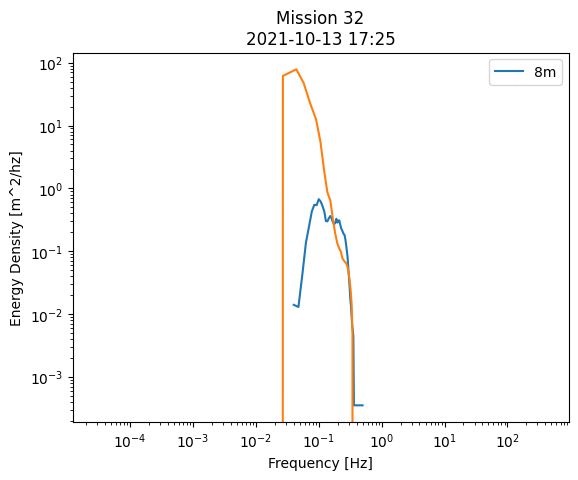

In [99]:
fig, ax = plt.subplots()
ax.loglog(freqs, spectra, label='8m')
plt.loglog([f.mean() for f in F], np.array(ff)/1e11)
# ax.loglog(w[:200]*2, np.mean(polar_image[:125, :150]*50, axis=0)*w[:200], label='img')
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Energy Density [m^2/hz]')
ax.set_title(
    f'Mission {mission_id}\n{mission_df_8m[(mission_df_8m['mission number'] == mission_id)]['time'].item()[:16]}')
plt.axis('equal')
plt.legend()
